<a href="https://colab.research.google.com/github/nishatsalsabilanisha/Colab-Notebooks/blob/slang_codes/bangla_bert_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Performing checks for the resources available

In [ ]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla T4


### Installing huggingface transformers library

In [ ]:
!pip install transformers

## Importing necessary packages

In [ ]:
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import time
import datetime
from sklearn.metrics import classification_report,confusion_matrix
import random
import time
import torch.nn as nn
from transformers import AutoModel , AutoModelForSequenceClassification, AutoConfig , AutoTokenizer
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
from matplotlib.ticker import MaxNLocator

## Setting some configuration values

In [ ]:
# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (16,12)

# Set the seed value all over the place to make this reproducible.
seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

## Loading training data

In [ ]:

train_df = pd.read_csv('/content/test.csv.csv')

# Report the number of sentences.
print('Number of training sentences: {:,}\n'.format(train_df.shape[0]))

# Display 10 random rows from the data.
train_df.sample(10)

Number of training sentences: 1,135



,PID,text,labels
784,test_id_6674,অাপনি কিন্ত অনেক ভালো খেলোয়াড়>বুঝলে বুঝ পাতা ন...,Negative
900,test_id_2938,হলে আধা পরিচিত মাল্টিপল কোয়েশ্চেন সামনে পড়লে ।,Positive
413,test_id_9074,কাজ করছে তাতে জোর সম্ভাবনা যে বায়ুমণ্ডলে ।,Positive
467,test_id_1965,কিন্তু লাউহে মাহফুজে সংরক্ষিত কুরআন ত আল্লাহ হ...,Neutral
746,test_id_8689,সবাই দালান কোঠা কিংবা টিনশেডের ঘরে থাকতে ।,Positive
109,test_id_10484,কষ্ট উড়াই হাওয়ায় মাঝে মাঝে তোমায় সাজাই ।,Positive
522,test_id_7143,আপনি তো আরো আগেই জিতে গেছেন দিদি! যখন বা** খুল...,Negative
56,test_id_8748,প্যানেলের মাধ্যমে এ শক্তি আহরণ করা হয় ।,Positive
1014,test_id_8264,“বিজয় দিবসের শুভেচ্ছা”,Neutral
964,test_id_7075,খানকি নাকি পরকাল বিলিভ করে না।বেস্যা,Negative


In [ ]:
train_df

,PID,text,labels
0,test_id_11340,না থাকলে শুধু ‘প্রাইমারি শিক্ষক নিয়োগ বইটির সা...,Positive
1,test_id_3894,অনেক তো ঢাললা এবার খুলে দেও,Negative
2,test_id_7304,"ভাইয়া, আইফোন একটা চালাইলে-ই অন্য ব্যান্ডের সাথ...",Neutral
3,test_id_4553,বিএনপিরই উচিৎ ছিল জামাতকে ছাড়া। কিন্তু ঘটেছে উ...,Neutral
4,test_id_9912,তারার পানে চেয়ে চেয়ে নাইবা আমায় ডাকলে তখন ।,Positive
...,...,...,...
1130,test_id_6995,আপু আমি তোমাকে সাপর্ট করছি চোদার জন্য .অন...,Negative
1131,test_id_11162,আমি কীভাবে এতো অল্প সময়ে ভালো প্রস্তুতি ।,Positive
1132,test_id_2691,কারণ তার আগের দিন আলিনূর একটা ঘটনা ।,Positive
1133,test_id_9055,করে কাজে লাগাতে হলে দরকার সূর্য সম্বন্ধে বিস্ত...,Positive


In [ ]:
train_df['labels'].value_counts()

,count
labels,
Positive,456
Neutral,356
Negative,323


In [ ]:

le = LabelEncoder()
train_df['labels'] = le.fit_transform(train_df['labels'])

In [ ]:
train_df['labels'].value_counts()

,count
labels,
2,456
1,356
0,323


### Loading `train_sentences` and `train_labels`

In [ ]:
# Get the lists of sentences and their labels.
train_sentences = train_df['text'].values
train_labels = train_df['labels'].values

## Saving Class Names

In [ ]:
class_names = [
               'Negative','Positive','Neutral'
]

## Loading the validation data

In [ ]:
# val_df_path = join(dataset_dir,'tamil_offensive_full_dev_corrected.csv')
# Load the dataset into a pandas dataframe.
val_df = pd.read_csv('/content/val.csv.csv')

# Report the number of sentences.
print('Number of training sentences: {:,}\n'.format(val_df.shape[0]))

# Display 10 random rows from the data.
val_df.sample(10)

Number of training sentences: 1,134



,PID,text,labels
1096,test_id_2909,সে সঙ্গে মনের রাগ প্রকাশ করছি অনুপস্থিত ।,Positive
580,test_id_8763,উন্নত পর্যায়ে নিয়ে যেতে দরকার আরও আরও ।,Positive
582,test_id_1392,দুর্নীতিবাজদের মাঝে ভয়ের সৃষ্টিই দুর্নীতি দমন...,Neutral
247,test_id_2519,তিন-চার দিনের মধ্যে গাছটা মরে কাঠ হয়ে গেল ।,Positive
143,test_id_1677,এই ধরনের গুরুত্বপূর্ণ লেখার জন্য,Neutral
874,test_id_9953,সকল খেলায় করবে খেলা এই আমি - আহা ।,Positive
278,test_id_699,তোর ফেসবুক প্রোফাইল তো গেছে এবার তোর পেজ চলে য...,Negative
430,test_id_8093,“ঐক্যফ্রন্ট মানলেই কি আর না মানলেই বা কি “ ?,Neutral
1099,test_id_8039,রাজনীতির এই অসুস্থ চর্চার খবর পড়া কবে বন্ধ হবে?,Neutral
438,test_id_1670,তোমাদের জন্য,Neutral


In [ ]:
val_df['labels'].value_counts()

,count
labels,
Positive,456
Neutral,355
Negative,323


In [ ]:
val_df['labels'] = le.transform(val_df['labels'])

In [ ]:

val_df['labels'].value_counts()

,count
labels,
2,456
1,355
0,323


### Loading `val_sentences` and `val_labels`

In [ ]:
# Get the lists of sentences and their labels.
val_sentences = val_df['text'].values
val_labels = val_df['labels'].values

###Bangla Stopword Removal (before tokenization)

In [ ]:
# ======================================================
# 🧹 Bangla Stopword Removal (Manual List Fallback)
# ======================================================

bangla_stopwords = set([
    'আমি','তুমি','সে','তারা','আমরা','যে','যা','এই','ওই','এবং','কিন্তু','তবে','যদি','যখন','তখন','কেন','কোথায়','কেমন','তাতে','এর','ছিল','হয়','ছিলো'
    # 👉 You can expand this list later if needed
])

import re

def clean_bangla_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"[^\u0980-\u09FF\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in bangla_stopwords]
    return " ".join(words)

train_df['text'] = train_df['text'].astype(str).apply(clean_bangla_text)
val_df['text'] = val_df['text'].astype(str).apply(clean_bangla_text)
print("✅ Stopwords removed successfully (Manual Fallback).")

✅ Stopwords removed successfully (Manual Fallback).


In [ ]:
train_df['text'] = train_df['text'].astype(str).apply(clean_bangla_text)
val_df['text'] = val_df['text'].astype(str).apply(clean_bangla_text)
print("✅ Stopwords removed successfully (Manual Fallback).")

✅ Stopwords removed successfully (Manual Fallback).


## Helper Functions

#### 1) Update Interval Function

In [ ]:
def good_update_interval(total_iters, num_desired_updates):
    '''
    This function will try to pick an intelligent progress update interval
    based on the magnitude of the total iterations.

    Parameters:
      `total_iters` - The number of iterations in the for-loop.
      `num_desired_updates` - How many times we want to see an update over the
                              course of the for-loop.
    '''
    # Divide the total iterations by the desired number of updates. Most likely
    # this will be some ugly number.
    exact_interval = total_iters / num_desired_updates

    # The `round` function has the ability to round down a number to, e.g., the
    # nearest thousandth: round(exact_interval, -3)
    #
    # To determine the magnitude to round to, find the magnitude of the total,
    # and then go one magnitude below that.

    # Get the order of magnitude of the total.
    order_of_mag = len(str(total_iters)) - 1

    # Our update interval should be rounded to an order of magnitude smaller.
    round_mag = order_of_mag - 1

    # Round down and cast to an int.
    update_interval = int(round(exact_interval, -round_mag))

    # Don't allow the interval to be zero!
    if update_interval == 0:
        update_interval = 1

    return update_interval

#### 2) Format time function

In [ ]:
def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))

    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))


#### 3) Make Smart Batches function

In [ ]:
def make_smart_batches(text_samples, labels, batch_size,tokenizer,max_input_length):
    '''
    This function combines all of the required steps to prepare batches.
    '''

    print('Creating Smart Batches from {:,} examples with batch size {:,}...\n'.format(len(text_samples), batch_size))

    # =========================
    #   Tokenize & Truncate
    # =========================

    full_input_ids = []

    # Tokenize all training examples
    print('Tokenizing {:,} samples...'.format(len(labels)))

    # Choose an interval on which to print progress updates.
    update_interval = good_update_interval(total_iters=len(labels), num_desired_updates=10)

    # For each training example...
    for text in text_samples:

        # Report progress.
        if ((len(full_input_ids) % update_interval) == 0):
            print('  Tokenized {:,} samples.'.format(len(full_input_ids)))

        # Tokenize the sample.
        input_ids = tokenizer.encode(text=text,              # Text to encode.
                                    add_special_tokens=True, # Do add specials.
                                    max_length=max_input_length,
                                    truncation=True,         # Do Truncate!
                                    padding=False)           # DO NOT pad.

        # Add the tokenized result to our list.
        full_input_ids.append(input_ids)

    print('DONE.')
    print('{:>10,} samples\n'.format(len(full_input_ids)))

    # =========================
    #      Select Batches
    # =========================

    # Sort the two lists together by the length of the input sequence.
    samples = sorted(zip(full_input_ids, labels), key=lambda x: len(x[0]))

    print('{:>10,} samples after sorting\n'.format(len(samples)))

    import random

    # List of batches that we'll construct.
    batch_ordered_sentences = []
    batch_ordered_labels = []

    print('Creating batches of size {:}...'.format(batch_size))

    # Choose an interval on which to print progress updates.
    update_interval = good_update_interval(total_iters=len(samples), num_desired_updates=10)

    # Loop over all of the input samples...
    while len(samples) > 0:

        # Report progress.
        if ((len(batch_ordered_sentences) % update_interval) == 0 \
            and not len(batch_ordered_sentences) == 0):
            print('  Selected {:,} batches.'.format(len(batch_ordered_sentences)))

        # `to_take` is our actual batch size. It will be `batch_size` until
        # we get to the last batch, which may be smaller.
        to_take = min(batch_size, len(samples))

        # Pick a random index in the list of remaining samples to start
        # our batch at.
        select = random.randint(0, len(samples) - to_take)

        # Select a contiguous batch of samples starting at `select`.
        #print("Selecting batch from {:} to {:}".format(select, select+to_take))
        batch = samples[select:(select + to_take)]

        #print("Batch length:", len(batch))

        # Each sample is a tuple--split them apart to create a separate list of
        # sequences and a list of labels for this batch.
        batch_ordered_sentences.append([s[0] for s in batch])
        batch_ordered_labels.append([s[1] for s in batch])

        # Remove these samples from the list.
        del samples[select:select + to_take]

    print('\n  DONE - Selected {:,} batches.\n'.format(len(batch_ordered_sentences)))

    # =========================
    #        Add Padding
    # =========================

    print('Padding out sequences within each batch...')

    py_inputs = []
    py_attn_masks = []
    py_labels = []

    # For each batch...
    for (batch_inputs, batch_labels) in zip(batch_ordered_sentences, batch_ordered_labels):

        # New version of the batch, this time with padded sequences and now with
        # attention masks defined.
        batch_padded_inputs = []
        batch_attn_masks = []

        # First, find the longest sample in the batch.
        # Note that the sequences do currently include the special tokens!
        max_size = max([len(sen) for sen in batch_inputs])

        # For each input in this batch...
        for sen in batch_inputs:

            # How many pad tokens do we need to add?
            num_pads = max_size - len(sen)

            # Add `num_pads` padding tokens to the end of the sequence.
            padded_input = sen + [tokenizer.pad_token_id]*num_pads

            # Define the attention mask--it's just a `1` for every real token
            # and a `0` for every padding token.
            attn_mask = [1] * len(sen) + [0] * num_pads

            # Add the padded results to the batch.
            batch_padded_inputs.append(padded_input)
            batch_attn_masks.append(attn_mask)

        # Our batch has been padded, so we need to save this updated batch.
        # We also need the inputs to be PyTorch tensors, so we'll do that here.
        # Todo - Michael's code specified "dtype=torch.long"
        py_inputs.append(torch.tensor(batch_padded_inputs))
        py_attn_masks.append(torch.tensor(batch_attn_masks))
        py_labels.append(torch.tensor(batch_labels))

    print('  DONE.')

    # Return the smart-batched dataset!
    return (py_inputs, py_attn_masks, py_labels)


In [ ]:
def make_smart_batches_on_test(text_samples, text_ids, batch_size,tokenizer,max_input_length):
    '''
    This function combines all of the required steps to prepare batches.
    '''

    print('Creating Smart Batches from {:,} examples with batch size {:,}...\n'.format(len(text_samples), batch_size))

    # =========================
    #   Tokenize & Truncate
    # =========================

    full_input_ids = []

    # Tokenize all training examples
    print('Tokenizing {:,} samples...'.format(len(text_samples)))

    # Choose an interval on which to print progress updates.
    update_interval = good_update_interval(total_iters=len(text_samples), num_desired_updates=10)

    # For each training example...
    for text in text_samples:

        # Report progress.
        if ((len(full_input_ids) % update_interval) == 0):
            print('  Tokenized {:,} samples.'.format(len(full_input_ids)))

        # Tokenize the sample.
        input_ids = tokenizer.encode(text=text,              # Text to encode.
                                    add_special_tokens=True, # Do add specials.
                                    max_length=max_input_length,
                                    truncation=True,         # Do Truncate!
                                    padding=False)           # DO NOT pad.

        # Add the tokenized result to our list.
        full_input_ids.append(input_ids)

    print('DONE.')
    print('{:>10,} samples\n'.format(len(full_input_ids)))

    # =========================
    #      Select Batches
    # =========================

    # Sort the two lists together by the length of the input sequence.
    samples = sorted(zip(full_input_ids, text_ids), key=lambda x: len(x[0]))

    print('{:>10,} samples after sorting\n'.format(len(samples)))

    import random

    # List of batches that we'll construct.
    batch_ordered_sentences = []
    batch_ordered_ids = []

    print('Creating batches of size {:}...'.format(batch_size))

    # Choose an interval on which to print progress updates.
    update_interval = good_update_interval(total_iters=len(samples), num_desired_updates=10)

    # Loop over all of the input samples...
    while len(samples) > 0:

        # Report progress.
        if ((len(batch_ordered_sentences) % update_interval) == 0 \
            and not len(batch_ordered_sentences) == 0):
            print('  Selected {:,} batches.'.format(len(batch_ordered_sentences)))

        # `to_take` is our actual batch size. It will be `batch_size` until
        # we get to the last batch, which may be smaller.
        to_take = min(batch_size, len(samples))

        # Pick a random index in the list of remaining samples to start
        # our batch at.
        select = random.randint(0, len(samples) - to_take)

        # Select a contiguous batch of samples starting at `select`.
        #print("Selecting batch from {:} to {:}".format(select, select+to_take))
        batch = samples[select:(select + to_take)]

        #print("Batch length:", len(batch))

        # Each sample is a tuple--split them apart to create a separate list of
        # sequences and a list of labels for this batch.
        batch_ordered_sentences.append([s[0] for s in batch])
        batch_ordered_ids.append([s[1] for s in batch])

        # Remove these samples from the list.
        del samples[select:select + to_take]

    print('\n  DONE - Selected {:,} batches.\n'.format(len(batch_ordered_sentences)))

    # =========================
    #        Add Padding
    # =========================

    print('Padding out sequences within each batch...')

    py_inputs = []
    py_attn_masks = []
    py_ids = []

    # For each batch...
    for (batch_inputs, batch_ids) in zip(batch_ordered_sentences, batch_ordered_ids):

        # New version of the batch, this time with padded sequences and now with
        # attention masks defined.
        batch_padded_inputs = []
        batch_attn_masks = []

        # First, find the longest sample in the batch.
        # Note that the sequences do currently include the special tokens!
        max_size = max([len(sen) for sen in batch_inputs])

        # For each input in this batch...
        for sen in batch_inputs:

            # How many pad tokens do we need to add?
            num_pads = max_size - len(sen)

            # Add `num_pads` padding tokens to the end of the sequence.
            padded_input = sen + [tokenizer.pad_token_id]*num_pads

            # Define the attention mask--it's just a `1` for every real token
            # and a `0` for every padding token.
            attn_mask = [1] * len(sen) + [0] * num_pads

            # Add the padded results to the batch.
            batch_padded_inputs.append(padded_input)
            batch_attn_masks.append(attn_mask)

        # Our batch has been padded, so we need to save this updated batch.
        # We also need the inputs to be PyTorch tensors, so we'll do that here.
        # Todo - Michael's code specified "dtype=torch.long"
        py_inputs.append(torch.tensor(batch_padded_inputs))
        py_attn_masks.append(torch.tensor(batch_attn_masks))
        py_ids.append(torch.tensor(batch_ids))

    print('  DONE.')

    # Return the smart-batched dataset!
    return (py_inputs, py_attn_masks, py_ids)


#### 4) Function for calculating accuracy per class

In [ ]:
def accuracy_per_class(preds, labels , label_dict):

    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()

    for label in np.unique(labels_flat):
        y_preds = preds_flat[labels_flat==label]
        y_true = labels_flat[labels_flat==label]
        print(f'Class: {label_dict[label]}')
        print(f'Accuracy: {round(100*len(y_preds[y_preds==label])/len(y_true) , 2)}\n')

### 5) Function for plotting training history

In [ ]:
def plot_training_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

  ax1.plot(history['train_loss'], label='train loss')
  ax1.plot(history['val_loss'], label='validation loss')

  ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax1.set_ylim([-0.05, 1.05])
  ax1.legend()
  ax1.set_ylabel('Loss')
  ax1.set_xlabel('Epoch')

  ax2.plot(history['train_acc'], label='train accuracy')
  ax2.plot(history['val_acc'], label='validation accuracy')

  ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax2.set_ylim([-0.05, 1.05])
  ax2.legend()

  ax2.set_ylabel('Accuracy')
  ax2.set_xlabel('Epoch')

  fig.suptitle('Training history')

### 6) Function to check accuracy

In [ ]:
def check_accuracy(predictions,true_labels):
  # Combine the results across the batches.
  predictions = np.concatenate(predictions, axis=0)
  true_labels = np.concatenate(true_labels, axis=0)

  # Choose the label with the highest score as our prediction.
  preds = np.argmax(predictions, axis=1).flatten()

  # Calculate simple flat accuracy -- number correct over total number.
  accuracy = (preds == true_labels).mean()

  return accuracy

### 7) Function to evaluate model

In [ ]:
def eval_model(model,py_inputs, py_attn_masks, py_labels):
# Prediction on test set
  t0 = time.time()

  print('Doing validation on {:,} sentences...'.format(len(py_labels)))

  # Put model in evaluation mode
  model.eval()

  # Tracking variables
  predictions , true_labels = [], []

  # Choose an interval on which to print progress updates.
  update_interval = good_update_interval(total_iters=len(py_inputs), num_desired_updates=10)

  # Measure elapsed time.
  t0 = time.time()
  total_val_loss = 0

  # Put model in evaluation mode
  model.eval()

  # For each batch of training data...
  for step in range(0, len(py_inputs)):

      # Progress update every 100 batches.
      if step % update_interval == 0 and not step == 0:
          # Calculate elapsed time in minutes.
          elapsed = format_time(time.time() - t0)

          # Calculate the time remaining based on our progress.
          steps_per_sec = (time.time() - t0) / step
          remaining_sec = steps_per_sec * (len(py_inputs) - step)
          remaining = format_time(remaining_sec)

          # Report progress.
          print('  Batch {:>7,}  of  {:>7,}.    Elapsed: {:}.  Remaining: {:}'.format(step, len(py_inputs), elapsed, remaining))

      # Copy the batch to the GPU.
      b_input_ids = py_inputs[step].to(device)
      b_input_mask = py_attn_masks[step].to(device)
      b_labels = py_labels[step].to(device)

      # Telling the model not to compute or store gradients, saving memory and
      # speeding up prediction
      with torch.no_grad():
        output = model(b_input_ids,
                             token_type_ids=None,
                             attention_mask=b_input_mask,
                             labels=b_labels)


      logits = output.logits
      loss = output.loss
      # Move logits and labels to CPU
      logits = logits.detach().cpu().numpy()
      label_ids = b_labels.to('cpu').numpy()

      # Store predictions and true labels
      predictions.append(logits)
      true_labels.append(label_ids)

      total_val_loss += loss.item()

  val_accuracy = check_accuracy(predictions,true_labels)

  validation_time = format_time(time.time() - t0)

  # Calculate the average loss over all of the batches.
  avg_val_loss = total_val_loss / len(py_inputs)


  # print('Accuracy: {:.3f}'.format(val_accuracy))
  return (avg_val_loss,val_accuracy,validation_time)


### 8) Function for making predictions on our test dataset

In [ ]:
def get_predictions(py_inputs, py_attn_masks, py_labels):

  print('Predicting labels for {:,} test batches...'.format(len(py_labels)))

  # Put model in evaluation mode
  model.eval()

  # Tracking variables
  predictions , true_labels = [], []

  # Choose an interval on which to print progress updates.
  update_interval = good_update_interval(total_iters=len(py_inputs), num_desired_updates=10)

  # Measure elapsed time.
  t0 = time.time()

  # Put model in evaluation mode
  model.eval()

  # For each batch of training data...
  for step in range(0, len(py_inputs)):

      # Progress update every 100 batches.
      if step % update_interval == 0 and not step == 0:
          # Calculate elapsed time in minutes.
          elapsed = format_time(time.time() - t0)

          # Calculate the time remaining based on our progress.
          steps_per_sec = (time.time() - t0) / step
          remaining_sec = steps_per_sec * (len(py_inputs) - step)
          remaining = format_time(remaining_sec)

          # Report progress.
          print('  Batch {:>7,}  of  {:>7,}.    Elapsed: {:}.  Remaining: {:}'.format(step, len(py_inputs), elapsed, remaining))

      # Copy the batch to the GPU.
      b_input_ids = py_inputs[step].to(device)
      b_input_mask = py_attn_masks[step].to(device)
      b_labels = py_labels[step].to(device)

      # Telling the model not to compute or store gradients, saving memory and
      # speeding up prediction
      with torch.no_grad():
          # Forward pass, calculate logit predictions
          outputs = model(b_input_ids, b_input_mask)

      logits = outputs.logits

      # Move logits and labels to CPU
      logits = logits.detach().cpu().numpy()
      label_ids = b_labels.to('cpu').numpy()

      # Store predictions and true labels
      predictions.append(logits)
      true_labels.append(label_ids)
      # Combine the results across the batches.
  predictions = np.concatenate(predictions, axis=0)
  true_labels = np.concatenate(true_labels, axis=0)

      # Choose the label with the highest score as our prediction.
  preds = np.argmax(predictions, axis=1).flatten()

  return (preds,true_labels)

### 9) Function for making predictions on test dataset(without labels)

In [ ]:
def get_predictions_test(py_inputs, py_attn_masks,py_ids):

  print('Predicting labels for {:,} test batches...'.format(len(py_inputs)))

  # Put model in evaluation mode
  model.eval()

  # Tracking variables
  predictions , true_labels ,ids = [], [] , []

  # Choose an interval on which to print progress updates.
  update_interval = good_update_interval(total_iters=len(py_inputs), num_desired_updates=10)

  # Measure elapsed time.
  t0 = time.time()

  # Put model in evaluation mode
  model.eval()

  # For each batch of training data...
  for step in range(0, len(py_inputs)):

      # Progress update every 100 batches.
      if step % update_interval == 0 and not step == 0:
          # Calculate elapsed time in minutes.
          elapsed = format_time(time.time() - t0)

          # Calculate the time remaining based on our progress.
          steps_per_sec = (time.time() - t0) / step
          remaining_sec = steps_per_sec * (len(py_inputs) - step)
          remaining = format_time(remaining_sec)

          # Report progress.
          print('  Batch {:>7,}  of  {:>7,}.    Elapsed: {:}.  Remaining: {:}'.format(step, len(py_inputs), elapsed, remaining))

      # Copy the batch to the GPU.
      b_input_ids = py_inputs[step].to(device)
      b_input_mask = py_attn_masks[step].to(device)
      b_ids = py_ids[step].to(device)

      # Telling the model not to compute or store gradients, saving memory and
      # speeding up prediction
      with torch.no_grad():
          # Forward pass, calculate logit predictions
          outputs = model(b_input_ids, b_input_mask)

      logits = outputs.logits

      # Move logits and labels to CPU
      logits = logits.detach().cpu().numpy()
      b_ids = b_ids.detach().cpu().numpy()
      # Store predictions
      predictions.append(logits)
      ids.append(b_ids)
      # Combine the results across the batches.
  predictions = np.concatenate(predictions, axis=0)
  ids = np.concatenate(ids,axis=0)
  # Choose the label with the highest score as our prediction.
  preds = np.argmax(predictions, axis=1).flatten()

  return ids,preds

### 10) Confusion Matrix Helper Function

In [ ]:
def show_confusion_matrix(confusion_matrix, class_names):

  cm = confusion_matrix.copy()

  cell_counts = cm.flatten()

  cm_row_norm = cm / cm.sum(axis=1)[:, np.newaxis]

  row_percentages = ["{0:.2f}".format(value) for value in cm_row_norm.flatten()]

  cell_labels = [f"{cnt}\n{per}" for cnt, per in zip(cell_counts, row_percentages)]
  cell_labels = np.asarray(cell_labels).reshape(cm.shape[0], cm.shape[1])

  df_cm = pd.DataFrame(cm_row_norm, index=class_names, columns=class_names)

  hmap = sns.heatmap(df_cm, annot=cell_labels, fmt="", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True Sign')
  plt.xlabel('Predicted Sign');

## Smart Batching of the training data

In [ ]:

model_name='sagorsarker/bangla-bert-base'
# Load the BERT tokenizer.
print(f'Loading {model_name} tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)

Loading sagorsarker/bangla-bert-base tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
lengths = []
for text in train_sentences:
  lengths.append(len(text))

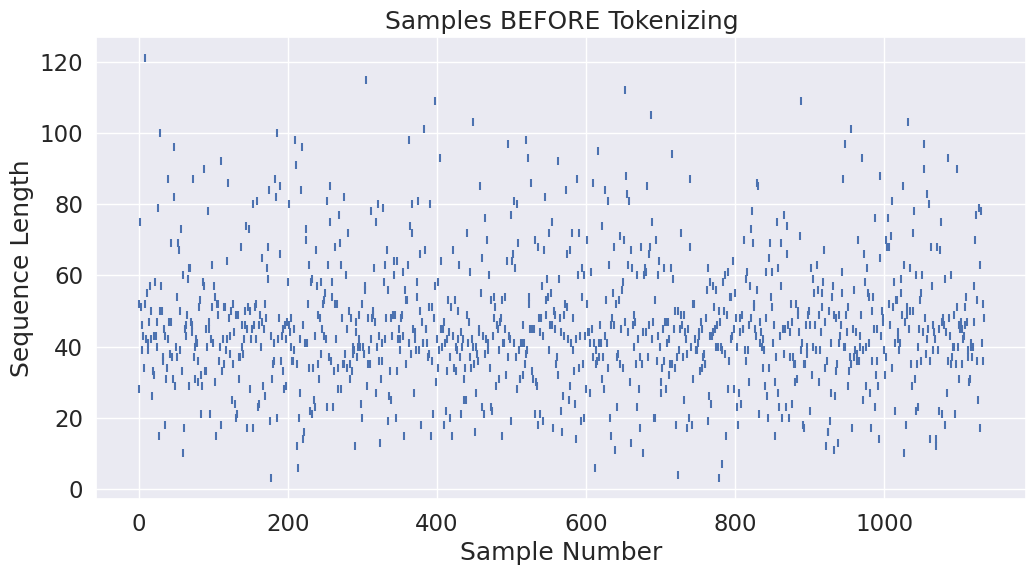

In [ ]:

# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

plt.scatter(range(0, len(lengths)), lengths, marker="|")

plt.xlabel('Sample Number')
plt.ylabel('Sequence Length')
plt.title('Samples BEFORE Tokenizing')

plt.show()

### Tokenizing the sequences

In [ ]:
max_input_length = 400

In [ ]:
full_input_ids = []
labels = []

# Tokenize all training examples
print('Tokenizing {:,} training samples...'.format(len(train_sentences)))

# Choose an interval on which to print progress updates.
update_interval = good_update_interval(total_iters=len(train_sentences), num_desired_updates=10)

# For each training example...
for text in train_sentences:

    # Report progress.
    if ((len(full_input_ids) % update_interval) == 0):
        print('  Tokenized {:,} samples.'.format(len(full_input_ids)))

    # Tokenize the sentence.
    input_ids = tokenizer.encode(text=text,
                                 add_special_tokens=True,
                                 max_length=max_input_length,
                                 truncation=True,
                                 padding=False)

    # Add the tokenized result to our list.
    full_input_ids.append(input_ids)

print('DONE.')
print('{:>10,} samples'.format(len(full_input_ids)))

Tokenizing 1,135 training samples...
  Tokenized 0 samples.
  Tokenized 100 samples.
  Tokenized 200 samples.
  Tokenized 300 samples.
  Tokenized 400 samples.
  Tokenized 500 samples.
  Tokenized 600 samples.
  Tokenized 700 samples.
  Tokenized 800 samples.
  Tokenized 900 samples.
  Tokenized 1,000 samples.
  Tokenized 1,100 samples.
DONE.
     1,135 samples


In [ ]:
# Get all of the lengths.
unsorted_lengths = [len(x) for x in full_input_ids]

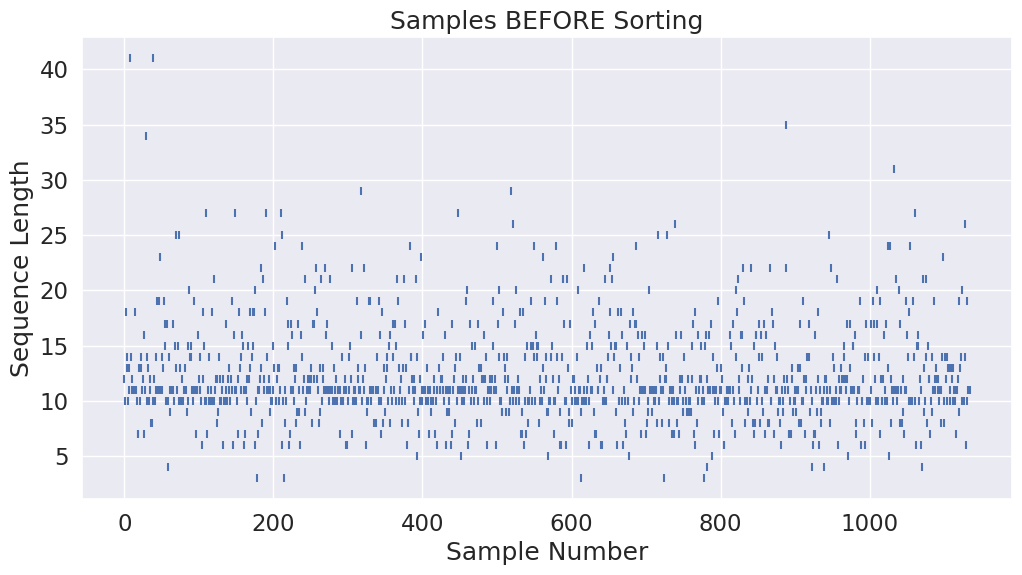

In [ ]:

# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

plt.scatter(range(0, len(unsorted_lengths)), unsorted_lengths, marker="|")

plt.xlabel('Sample Number')
plt.ylabel('Sequence Length')
plt.title('Samples BEFORE Sorting')

plt.show()

In [ ]:
# Sort the two lists together by the length of the input sequence.
train_samples = sorted(zip(full_input_ids, train_labels), key=lambda x: len(x[0]))

In [ ]:
train_samples[0:5]

[([101, 5477, 102], np.int64(1)),
 ([101, 5795, 102], np.int64(1)),
 ([101, 3676, 102], np.int64(1)),
 ([101, 3025, 102], np.int64(1)),
 ([101, 2087, 102], np.int64(1))]

In [ ]:
print('Shortest sample:', len(train_samples[0][0]))
print('Longest sample:', len(train_samples[-1][0]))

Shortest sample: 3
Longest sample: 41


In [ ]:
# Get the new list of lengths after sorting.
sorted_lengths = [len(s[0]) for s in train_samples]

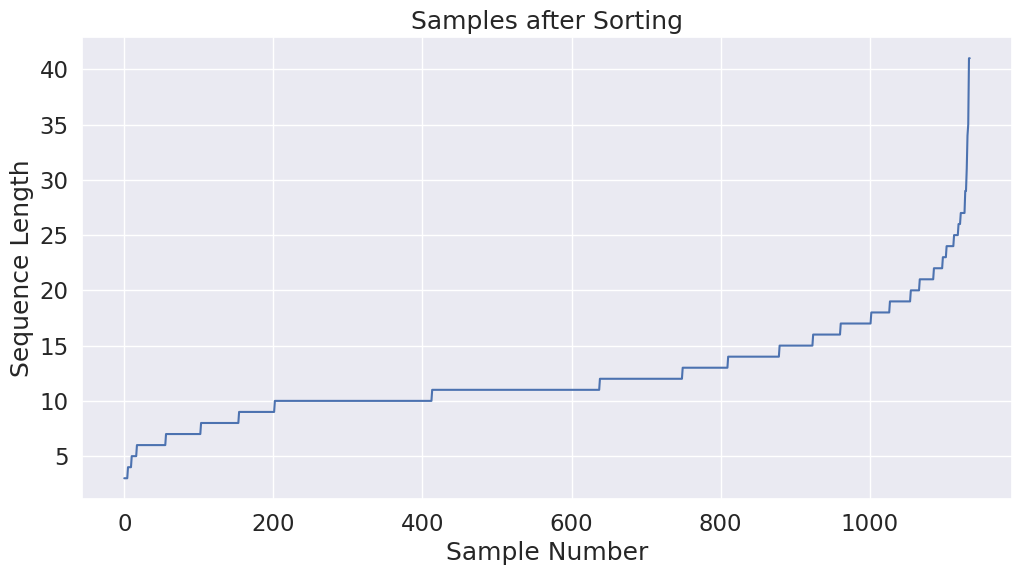

In [ ]:


plt.plot(range(0, len(sorted_lengths)), sorted_lengths)

plt.xlabel('Sample Number')
plt.ylabel('Sequence Length')
plt.title('Samples after Sorting')

plt.show()

### Random Batch Selections

In [ ]:
train_samples[0]

([101, 5477, 102], np.int64(1))

In [ ]:
batch_size = 16

In [ ]:
# List of batches that we'll construct.
batch_ordered_sentences = []
batch_ordered_labels = []

print('Creating training batches of size {:}'.format(batch_size))

# Loop over all of the input samples...
while len(train_samples) > 0:

    # Report progress.
    if ((len(batch_ordered_sentences) % 100) == 0):
        print('  Selected {:,} batches.'.format(len(batch_ordered_sentences)))

    # `to_take` is our actual batch size. It will be `batch_size` until
    # we get to the last batch, which may be smaller.
    to_take = min(batch_size, len(train_samples))

    # Pick a random index in the list of remaining samples to start
    # our batch at.
    select = random.randint(0, len(train_samples) - to_take)

    # Select a contiguous batch of samples starting at `select`.
    batch = train_samples[select:(select + to_take)]

    # Each sample is a tuple--split them apart to create a separate list of
    # sequences and a list of labels for this batch.
    batch_ordered_sentences.append([s[0] for s in batch])
    batch_ordered_labels.append([s[1] for s in batch])

    # Remove these samples from the list.
    del train_samples[select:select + to_take]

print('\n  DONE - {:,} batches.'.format(len(batch_ordered_sentences)))

Creating training batches of size 16
  Selected 0 batches.

  DONE - 71 batches.


In [ ]:
print(batch_ordered_sentences[0])

[[101, 12468, 4284, 29863, 4204, 12468, 7777, 5588, 21635, 102], [101, 3079, 2911, 2374, 2841, 2045, 2169, 1012, 1014, 102], [101, 100, 2154, 8802, 2196, 14691, 27497, 100, 2044, 102], [101, 50301, 100, 100, 2047, 10724, 100, 100, 1014, 102], [101, 8239, 2580, 100, 4430, 6108, 2071, 4617, 1014, 102], [101, 32363, 2043, 6758, 100, 4278, 2369, 4267, 1014, 102], [101, 5236, 2753, 2043, 2447, 8638, 2425, 2659, 1014, 102], [101, 17136, 6886, 100, 10195, 4173, 2468, 2055, 100, 102], [101, 60302, 2046, 2617, 50710, 9645, 38653, 4308, 999, 102], [101, 20813, 2438, 2470, 5549, 2596, 100, 2181, 2727, 102], [101, 3224, 3269, 2039, 2213, 7288, 3850, 2319, 1014, 102], [101, 15054, 2622, 100, 2683, 12057, 2089, 2106, 1014, 102], [101, 4619, 25804, 6296, 2154, 2085, 2080, 3408, 1014, 102], [101, 6123, 14362, 2211, 4532, 2253, 100, 2044, 1014, 102], [101, 2045, 2060, 2127, 3020, 14380, 4493, 38537, 2454, 102], [101, 2076, 2051, 3943, 14653, 2334, 2047, 100, 1014, 102]]


In [ ]:
batch_ordered_labels[0]

[np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(2)]

### Padding

In [ ]:
py_inputs = []
py_attn_masks = []
py_labels = []

# For each batch...
for (batch_inputs, batch_labels) in zip(batch_ordered_sentences, batch_ordered_labels):

    # New version of the batch, this time with padded sequences and now with
    # attention masks defined.
    batch_padded_inputs = []
    batch_attn_masks = []

    # First, find the longest sample in the batch.
    # Note that the sequences do currently include the special tokens!
    max_size = max([len(sen) for sen in batch_inputs])

    #print('Max size:', max_size)

    # For each input in this batch...
    for sen in batch_inputs:

        # How many pad tokens do we need to add?
        num_pads = max_size - len(sen)

        # Add `num_pads` padding tokens to the end of the sequence.
        padded_input = sen + [tokenizer.pad_token_id]*num_pads

        # Define the attention mask--it's just a `1` for every real token
        # and a `0` for every padding token.
        attn_mask = [1] * len(sen) + [0] * num_pads

        # Add the padded results to the batch.
        batch_padded_inputs.append(padded_input)
        batch_attn_masks.append(attn_mask)

    # Our batch has been padded, so we need to save this updated batch.
    # We also need the inputs to be PyTorch tensors, so we'll do that here.
    py_inputs.append(torch.tensor(batch_padded_inputs))
    py_attn_masks.append(torch.tensor(batch_attn_masks))
    py_labels.append(torch.tensor(batch_labels))


### Check the number of token reductions because of smart batching

In [ ]:
# Get the new list of lengths after sorting.

padded_lengths = []

# For each batch...
for batch in py_inputs:

    # For each sample...
    for s in batch:

        # Record its length.
        padded_lengths.append(len(s))

# Sum up the lengths to the get the total number of tokens after smart batching.
smart_token_count = np.sum(padded_lengths)

# To get the total number of tokens in the dataset using fixed padding, it's
# as simple as the number of samples times our `max_len` parameter (that we
# would pad everything to).
fixed_token_count = len(train_sentences) * max_input_length

# Calculate the percentage reduction.
prcnt_reduced = (fixed_token_count - smart_token_count) / float(fixed_token_count)

print('Total tokens:')
print('   Fixed Padding: {:,}'.format(fixed_token_count))
print('  Smart Batching: {:,}  ({:.1%} less)'.format(smart_token_count, prcnt_reduced))


Total tokens:
   Fixed Padding: 454,000
  Smart Batching: 14,887  (96.7% less)


## Load the model configuration from the transformers library using AutoConfig

In [ ]:
# Load the Config object, with an output configured for classification.
config = AutoConfig.from_pretrained(pretrained_model_name_or_path=model_name,
                                    num_labels=6)

print('Config type:', str(type(config)), '\n')


Config type: <class 'transformers.models.bert.configuration_bert.BertConfig'> 



In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name_or_path=model_name,config = config)

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sagorsarker/bangla-bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model.cuda()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(102025, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

## Load the model from the transformers library using AutoModel

In [ ]:
# Load the pre-trained model for classification, passing in the `config` from
# above.
bert = AutoModel.from_pretrained(
    pretrained_model_name_or_path=model_name,
    config=config)

print('\nModel type:', str(type(bert)))



Model type: <class 'transformers.models.bert.modeling_bert.BertModel'>


In [ ]:
# freeze all the parameters
for param in bert.parameters():
    param.requires_grad = False

## Loading Optimizer

In [ ]:
# Note: AdamW is a class from the huggingface library (as opposed to pytorch)
# I believe the 'W' stands for 'Weight Decay fix"
optimizer = AdamW(model.parameters(),
                  lr = 2e-5, # This is the value Michael used.
                  eps = 1e-8 # args.adam_epsilon  - default is 1e-8.
                )


## Loading lr scheduler

In [ ]:
# Number of training epochs. I chose to train for 1 simply because the training
# time is long. More epochs may improve the model's accuracy.
epochs = 5

# Total number of training steps is [number of batches] x [number of epochs].
# Note that it's the number of *batches*, not *samples*!
total_steps = len(py_inputs) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)

## Training Loop

In [ ]:
# We'll store a number of quantities such as training and validation loss,
# validation accuracy, and timings.
training_stats = {
    'epoch':[],
    'train_loss':[],
    'Training Time':[],
    'val_loss':[],
    'Validation Time':[],
    'train_acc':[],
    'val_acc':[]
}

# Update every `update_interval` batches.
update_interval = good_update_interval(total_iters=len(py_inputs), num_desired_updates=10)

# Measure the total training time for the whole run.
total_t0 = time.time()

# For each epoch...
for epoch_i in range(0, epochs):

    predictions = []
    true_labels = []

    # ========================================
    #               Training
    # ========================================

    # Perform one full pass over the training set.

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))

    # At the start of each epoch (except for the first) we need to re-randomize
    # our training data.
    if epoch_i > 0:
        # Use our `make_smart_batches` function (from 6.1.) to re-shuffle the
        # dataset into new batches.
        (py_inputs, py_attn_masks, py_labels) = make_smart_batches(train_sentences, train_labels, batch_size,tokenizer,max_input_length)

    print('Training on {:,} batches...'.format(len(py_inputs)))

    # Measure how long the training epoch takes.
    t0 = time.time()

    # Reset the total loss for this epoch.
    total_train_loss = 0

    # Put the model into training mode. Don't be mislead--the call to
    # `train` just changes the *mode*, it doesn't *perform* the training.
    # `dropout` and `batchnorm` layers behave differently during training
    # vs. test (source: https://stackoverflow.com/questions/51433378/what-does-model-train-do-in-pytorch)
    model.train()

    # For each batch of training data...
    for step in range(0, len(py_inputs)):

        # Progress update every, e.g., 100 batches.
        if step % update_interval == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = format_time(time.time() - t0)

            # Calculate the time remaining based on our progress.
            steps_per_sec = (time.time() - t0) / step
            remaining_sec = steps_per_sec * (len(py_inputs) - step)
            remaining = format_time(remaining_sec)

            # Report progress.
            print('  Batch {:>7,}  of  {:>7,}.    Elapsed: {:}.  Remaining: {:}'.format(step, len(py_inputs), elapsed, remaining))

        # Copy the current training batch to the GPU using the `to` method.
        b_input_ids = py_inputs[step].to(device)
        b_input_mask = py_attn_masks[step].to(device)
        b_labels = py_labels[step].to(device)

        # Always clear any previously calculated gradients before performing a
        # backward pass.
        model.zero_grad()

        # Perform a forward pass (evaluate the model on this training batch).
        # The call returns the loss (because we provided labels) and the
        # "logits"--the model outputs prior to activation.
        output = model(b_input_ids,
                             token_type_ids=None,
                             attention_mask=b_input_mask,
                             labels=b_labels)

        # Accumulate the training loss over all of the batches so that we can
        # calculate the average loss at the end. `loss` is a Tensor containing a
        # single value; the `.item()` function just returns the Python value
        # from the tensor.
        loss = output.loss
        logits = output.logits

        # Move logits and labels to CPU
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        # Store predictions and true labels
        predictions.append(logits)
        true_labels.append(label_ids)

        # Accumulate the training loss over all of the batches so that we can
        # calculate the average loss at the end. `loss` is a Tensor containing a
        # single value; the `.item()` function just returns the Python value
        # from the tensor.
        total_train_loss += loss.item()

        # Perform a backward pass to calculate the gradients.
        loss.backward()

        # Clip the norm of the gradients to 1.0.
        # This is to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters and take a step using the computed gradient.
        # The optimizer dictates the "update rule"--how the parameters are
        # modified based on their gradients, the learning rate, etc.
        optimizer.step()

        # Update the learning rate.
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(py_inputs)

    training_accuracy = check_accuracy(predictions,true_labels)

    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training Accuracy: {0:.2f}".format(training_accuracy))
    print("  Training epoch took: {:}".format(training_time))

    (py_inputs, py_attn_masks, py_labels) = make_smart_batches(val_sentences, val_labels, batch_size ,tokenizer,max_input_length)
    val_loss,val_accuracy,validation_time = eval_model(model,py_inputs, py_attn_masks, py_labels)
    # Record all statistics from this epoch.

    print("")
    print("  Average validation loss: {0:.2f}".format(val_loss))
    print("  Validation Accuracy: {0:.2f}".format(val_accuracy))
    print("  Validation epoch took: {:}".format(validation_time))


    training_stats['epoch'].append(epoch_i + 1)
    training_stats['train_loss'].append(avg_train_loss)
    training_stats['Training Time'].append(training_time)
    training_stats['val_loss'].append(val_loss)
    training_stats['Validation Time'].append(validation_time)
    training_stats['train_acc'].append(training_accuracy)
    training_stats['val_acc'].append(val_accuracy)

print("")
print("Training complete!")

print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


======== Epoch 1 / 5 ========
Training on 71 batches...
  Batch       7  of       71.    Elapsed: 0:00:03.  Remaining: 0:00:30
  Batch      14  of       71.    Elapsed: 0:00:05.  Remaining: 0:00:19
  Batch      21  of       71.    Elapsed: 0:00:06.  Remaining: 0:00:15
  Batch      28  of       71.    Elapsed: 0:00:08.  Remaining: 0:00:12
  Batch      35  of       71.    Elapsed: 0:00:09.  Remaining: 0:00:09
  Batch      42  of       71.    Elapsed: 0:00:10.  Remaining: 0:00:07
  Batch      49  of       71.    Elapsed: 0:00:10.  Remaining: 0:00:05
  Batch      56  of       71.    Elapsed: 0:00:11.  Remaining: 0:00:03
  Batch      63  of       71.    Elapsed: 0:00:12.  Remaining: 0:00:02
  Batch      70  of       71.    Elapsed: 0:00:14.  Remaining: 0:00:00

  Average training loss: 0.70
  Training Accuracy: 0.70
  Training epoch took: 0:00:14
Creating Smart Batches from 1,134 examples with batch size 16...

Tokenizing 1,134 samples...
  Tokenized 0 samples.
  Tokenized 100 samples.
  T

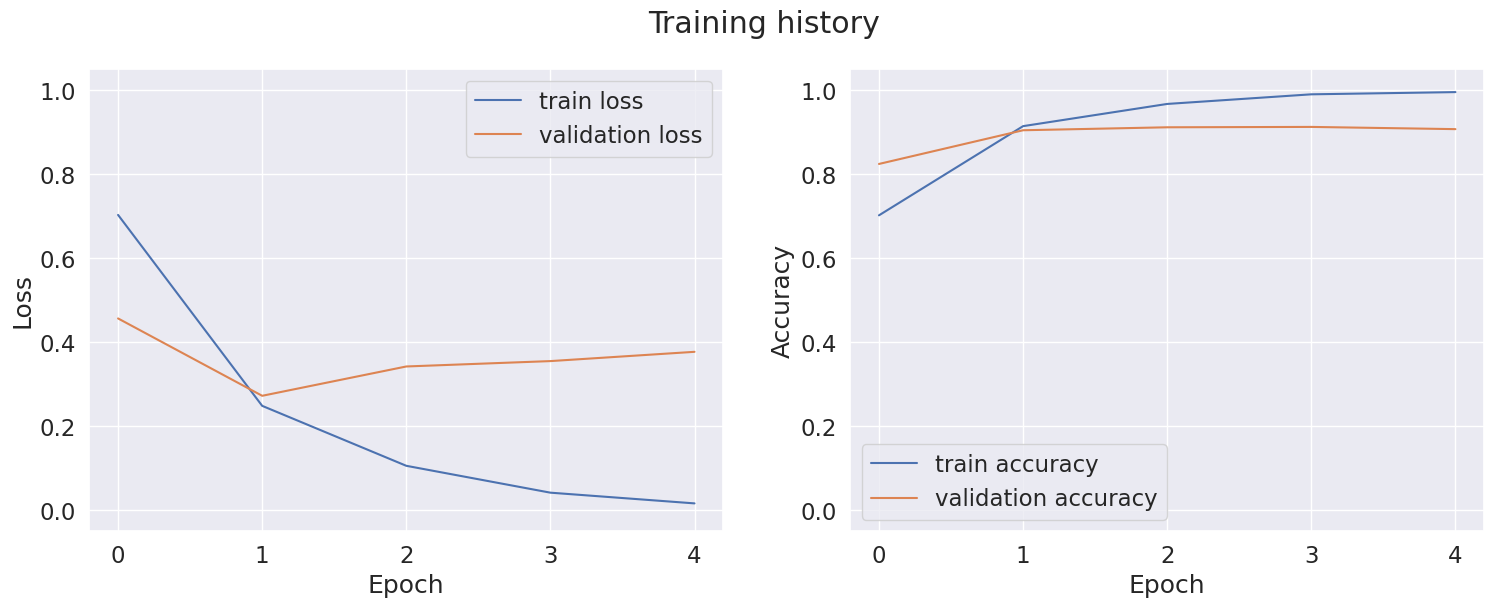

In [ ]:
plot_training_history(training_stats)

## Evaluating Performance Over Training Set

In [ ]:
(py_inputs, py_attn_masks, py_labels) = make_smart_batches(train_sentences, train_labels, batch_size ,tokenizer,max_input_length)

y_pred , y_true = get_predictions(py_inputs, py_attn_masks, py_labels)


Creating Smart Batches from 1,135 examples with batch size 16...

Tokenizing 1,135 samples...
  Tokenized 0 samples.
  Tokenized 100 samples.
  Tokenized 200 samples.
  Tokenized 300 samples.
  Tokenized 400 samples.
  Tokenized 500 samples.
  Tokenized 600 samples.
  Tokenized 700 samples.
  Tokenized 800 samples.
  Tokenized 900 samples.
  Tokenized 1,000 samples.
  Tokenized 1,100 samples.
DONE.
     1,135 samples

     1,135 samples after sorting

Creating batches of size 16...

  DONE - Selected 71 batches.

Padding out sequences within each batch...
  DONE.
Predicting labels for 71 test batches...
  Batch       7  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      14  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      21  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      28  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:01
  Batch      35  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:01
  Batch      42  of       71.    E

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       323
    Positive       1.00      0.99      1.00       356
     Neutral       1.00      1.00      1.00       456

    accuracy                           1.00      1135
   macro avg       1.00      1.00      1.00      1135
weighted avg       1.00      1.00      1.00      1135



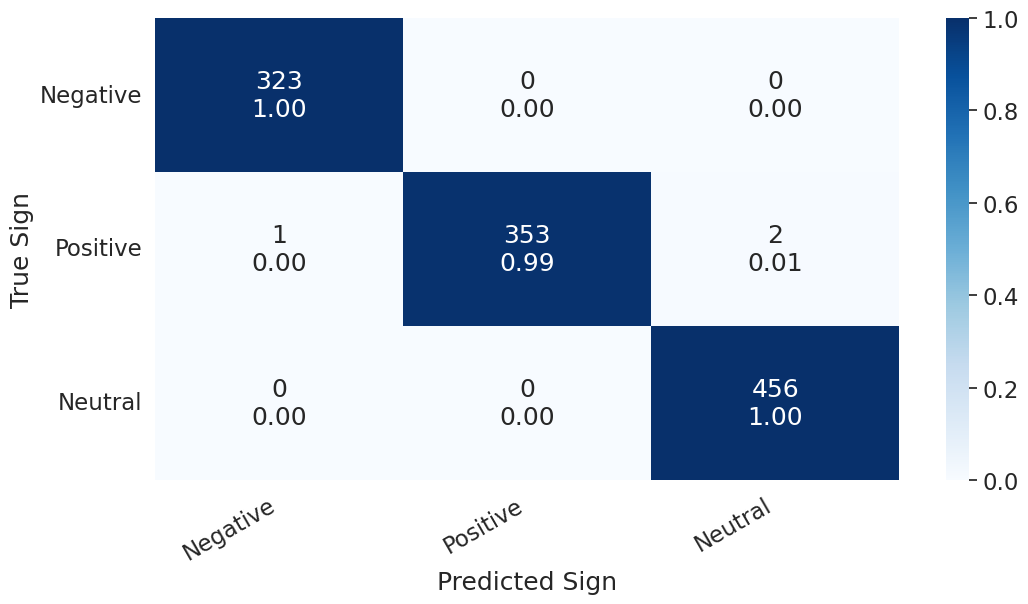

In [ ]:
cm = confusion_matrix(y_true, y_pred)
show_confusion_matrix(cm, class_names)

## Evaluating Performance Over Validation Set

In [ ]:
(py_inputs, py_attn_masks, py_labels) = make_smart_batches(val_sentences, val_labels, batch_size ,tokenizer,max_input_length)

y_pred , y_true = get_predictions(py_inputs, py_attn_masks, py_labels)

Creating Smart Batches from 1,134 examples with batch size 16...

Tokenizing 1,134 samples...
  Tokenized 0 samples.
  Tokenized 100 samples.
  Tokenized 200 samples.
  Tokenized 300 samples.
  Tokenized 400 samples.
  Tokenized 500 samples.
  Tokenized 600 samples.
  Tokenized 700 samples.
  Tokenized 800 samples.
  Tokenized 900 samples.
  Tokenized 1,000 samples.
  Tokenized 1,100 samples.
DONE.
     1,134 samples

     1,134 samples after sorting

Creating batches of size 16...

  DONE - Selected 71 batches.

Padding out sequences within each batch...
  DONE.
Predicting labels for 71 test batches...
  Batch       7  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      14  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      21  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      28  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      35  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:01
  Batch      42  of       71.    E

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Negative       0.91      0.86      0.89       323
    Positive       0.88      0.84      0.86       355
     Neutral       0.92      0.99      0.96       456

    accuracy                           0.91      1134
   macro avg       0.91      0.90      0.90      1134
weighted avg       0.91      0.91      0.91      1134



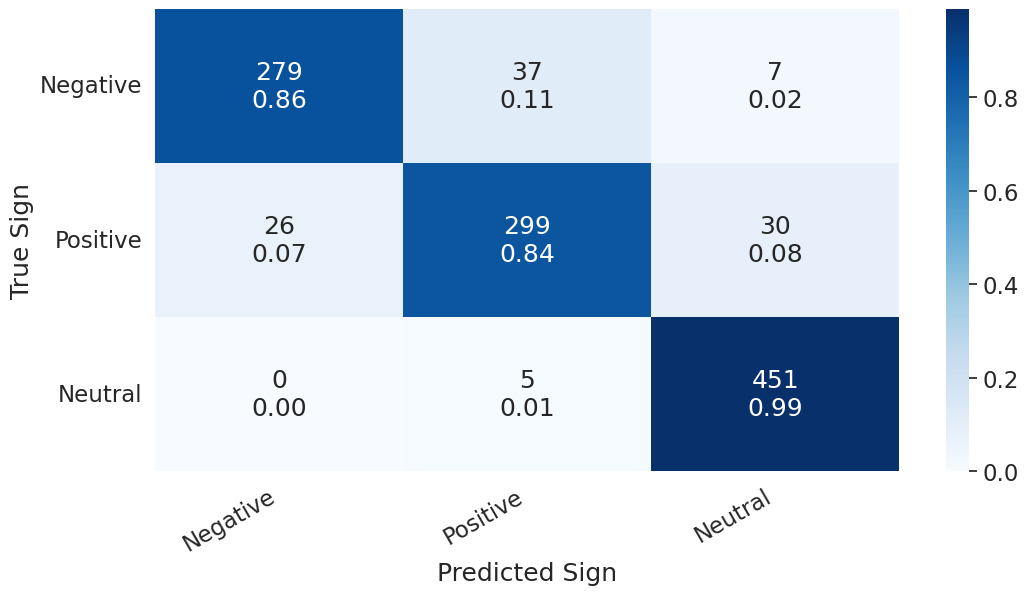

In [ ]:
cm = confusion_matrix(y_true, y_pred)
show_confusion_matrix(cm, class_names)

## Making Predictions on Test Set

In [ ]:
# test_df_path = join(dataset_dir,'tamil_offensive_full_test.csv')
test_df = pd.read_csv('/content/test.csv.csv')

In [ ]:
test_df

,PID,text,labels
0,test_id_11340,না থাকলে শুধু ‘প্রাইমারি শিক্ষক নিয়োগ বইটির সা...,Positive
1,test_id_3894,অনেক তো ঢাললা এবার খুলে দেও,Negative
2,test_id_7304,"ভাইয়া, আইফোন একটা চালাইলে-ই অন্য ব্যান্ডের সাথ...",Neutral
3,test_id_4553,বিএনপিরই উচিৎ ছিল জামাতকে ছাড়া। কিন্তু ঘটেছে উ...,Neutral
4,test_id_9912,তারার পানে চেয়ে চেয়ে নাইবা আমায় ডাকলে তখন ।,Positive
...,...,...,...
1130,test_id_6995,আপু আমি তোমাকে সাপর্ট করছি চোদার জন্য .অন...,Negative
1131,test_id_11162,আমি কীভাবে এতো অল্প সময়ে ভালো প্রস্তুতি ।,Positive
1132,test_id_2691,কারণ তার আগের দিন আলিনূর একটা ঘটনা ।,Positive
1133,test_id_9055,করে কাজে লাগাতে হলে দরকার সূর্য সম্বন্ধে বিস্ত...,Positive


## Loading `test_sentences`

In [ ]:
test_sentences = test_df['text'].values
test_labels = test_df['labels'].values
test_ids = test_df.index.values

In [ ]:
test_ids

array([   0,    1,    2, ..., 1132, 1133, 1134])

In [ ]:
(py_inputs, py_attn_masks,py_ids) = make_smart_batches_on_test(test_sentences,test_ids, 16,tokenizer,max_input_length)

Creating Smart Batches from 1,135 examples with batch size 16...

Tokenizing 1,135 samples...
  Tokenized 0 samples.
  Tokenized 100 samples.
  Tokenized 200 samples.
  Tokenized 300 samples.
  Tokenized 400 samples.
  Tokenized 500 samples.
  Tokenized 600 samples.
  Tokenized 700 samples.
  Tokenized 800 samples.
  Tokenized 900 samples.
  Tokenized 1,000 samples.
  Tokenized 1,100 samples.
DONE.
     1,135 samples

     1,135 samples after sorting

Creating batches of size 16...

  DONE - Selected 71 batches.

Padding out sequences within each batch...
  DONE.


In [ ]:
y_ids,y_preds  = get_predictions_test(py_inputs, py_attn_masks,py_ids)


Predicting labels for 71 test batches...
  Batch       7  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      14  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      21  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      28  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      35  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:01
  Batch      42  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:00
  Batch      49  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:00
  Batch      56  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:00
  Batch      63  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:00
  Batch      70  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:00


In [ ]:

test_sentences

array(['না থাকলে শুধু ‘প্রাইমারি শিক্ষক নিয়োগ বইটির সাজেশন ।',
       'অনেক তো ঢাললা এবার খুলে দেও',
       'ভাইয়া, আইফোন একটা চালাইলে-ই অন্য ব্যান্ডের সাথে এটার পার্থক্য বুঝতে পারবেন।',
       ..., 'কারণ তার আগের দিন আলিনূর একটা ঘটনা ।',
       'করে কাজে লাগাতে হলে দরকার সূর্য সম্বন্ধে বিস্তারিত ।',
       'সাঁইত্রিশ বছর আগে বাগানের এদিকটায় সাপে কেটেছিল ।'], dtype=object)

In [ ]:
(py_inputs, py_attn_masks,py_ids) = make_smart_batches_on_test(test_sentences,test_ids, 16,tokenizer,max_input_length)
y_pred , y_true = get_predictions(py_inputs, py_attn_masks, py_labels)

Creating Smart Batches from 1,135 examples with batch size 16...

Tokenizing 1,135 samples...
  Tokenized 0 samples.
  Tokenized 100 samples.
  Tokenized 200 samples.
  Tokenized 300 samples.
  Tokenized 400 samples.
  Tokenized 500 samples.
  Tokenized 600 samples.
  Tokenized 700 samples.
  Tokenized 800 samples.
  Tokenized 900 samples.
  Tokenized 1,000 samples.
  Tokenized 1,100 samples.
DONE.
     1,135 samples

     1,135 samples after sorting

Creating batches of size 16...

  DONE - Selected 71 batches.

Padding out sequences within each batch...
  DONE.
Predicting labels for 71 test batches...
  Batch       7  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      14  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      21  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      28  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      35  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:01
  Batch      42  of       71.    E

## Evaluating accuracy over test set

In [ ]:
y_ids,y_preds  = get_predictions_test(py_inputs, py_attn_masks,py_ids)


Predicting labels for 71 test batches...
  Batch       7  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      14  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      21  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      28  of       71.    Elapsed: 0:00:00.  Remaining: 0:00:01
  Batch      35  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:01
  Batch      42  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:00
  Batch      49  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:00
  Batch      56  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:00
  Batch      63  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:00
  Batch      70  of       71.    Elapsed: 0:00:01.  Remaining: 0:00:00


In [ ]:
print(y_preds)

[0 2 2 ... 0 0 0]


In [ ]:
print(y_ids)

[217 228 244 ... 716 728  39]


In [ ]:
le.inverse_transform(y_preds)

array(['Negative', 'Positive', 'Positive', ..., 'Negative', 'Negative',
       'Negative'], dtype=object)

<Axes: xlabel='count'>

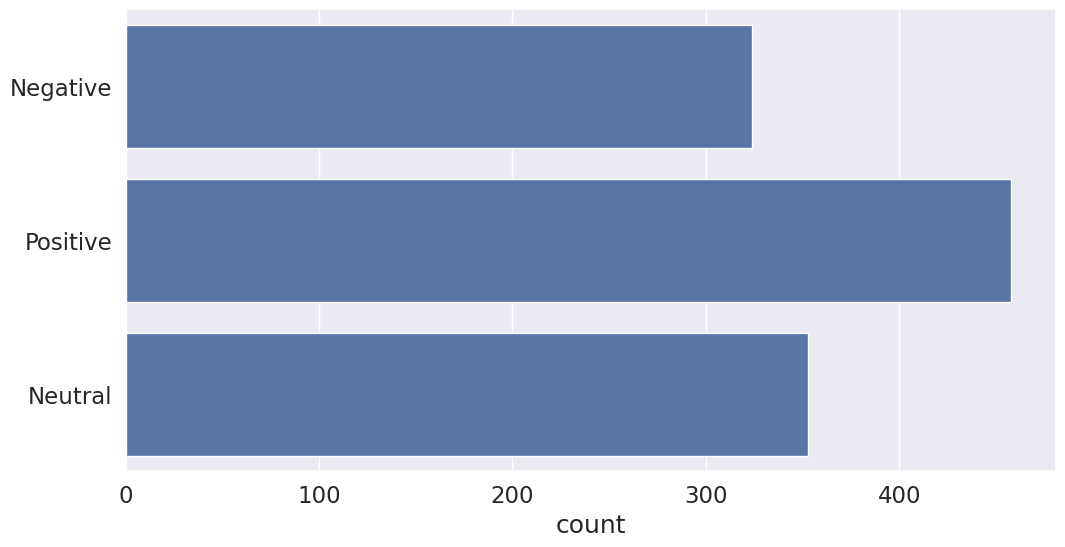

In [ ]:
sns.countplot(y =le.inverse_transform(y_preds))

In [ ]:
len(y_ids)

1135

In [ ]:
y_pred=le.inverse_transform(y_preds)
y_pred

array(['Negative', 'Positive', 'Positive', ..., 'Negative', 'Negative',
       'Negative'], dtype=object)

In [ ]:
len(y_pred)

1135

In [ ]:
test_labels

array(['Positive', 'Negative', 'Neutral', ..., 'Positive', 'Positive',
       'Positive'], dtype=object)

In [ ]:
len(y_preds)

1135

## Creating Submission DataFrame

In [ ]:


df_new = pd.DataFrame({
    'id':y_ids,
    'plabels':le.inverse_transform(y_preds)
})

In [ ]:

test_df['id'] = test_df.index

In [ ]:
df_new

,id,plabels
0,217,Negative
1,228,Positive
2,244,Positive
3,265,Negative
4,274,Positive
...,...,...
1130,828,Positive
1131,303,Neutral
1132,716,Negative
1133,728,Negative


In [ ]:
test_df

,PID,text,labels,id
0,test_id_11340,না থাকলে শুধু ‘প্রাইমারি শিক্ষক নিয়োগ বইটির সা...,Positive,0
1,test_id_3894,অনেক তো ঢাললা এবার খুলে দেও,Negative,1
2,test_id_7304,"ভাইয়া, আইফোন একটা চালাইলে-ই অন্য ব্যান্ডের সাথ...",Neutral,2
3,test_id_4553,বিএনপিরই উচিৎ ছিল জামাতকে ছাড়া। কিন্তু ঘটেছে উ...,Neutral,3
4,test_id_9912,তারার পানে চেয়ে চেয়ে নাইবা আমায় ডাকলে তখন ।,Positive,4
...,...,...,...,...
1130,test_id_6995,আপু আমি তোমাকে সাপর্ট করছি চোদার জন্য .অন...,Negative,1130
1131,test_id_11162,আমি কীভাবে এতো অল্প সময়ে ভালো প্রস্তুতি ।,Positive,1131
1132,test_id_2691,কারণ তার আগের দিন আলিনূর একটা ঘটনা ।,Positive,1132
1133,test_id_9055,করে কাজে লাগাতে হলে দরকার সূর্য সম্বন্ধে বিস্ত...,Positive,1133


In [ ]:
df_f = pd.merge(test_df,df_new,on = 'id')
df_f

,PID,text,labels,id,plabels
0,test_id_11340,না থাকলে শুধু ‘প্রাইমারি শিক্ষক নিয়োগ বইটির সা...,Positive,0,Positive
1,test_id_3894,অনেক তো ঢাললা এবার খুলে দেও,Negative,1,Negative
2,test_id_7304,"ভাইয়া, আইফোন একটা চালাইলে-ই অন্য ব্যান্ডের সাথ...",Neutral,2,Neutral
3,test_id_4553,বিএনপিরই উচিৎ ছিল জামাতকে ছাড়া। কিন্তু ঘটেছে উ...,Neutral,3,Neutral
4,test_id_9912,তারার পানে চেয়ে চেয়ে নাইবা আমায় ডাকলে তখন ।,Positive,4,Positive
...,...,...,...,...,...
1130,test_id_6995,আপু আমি তোমাকে সাপর্ট করছি চোদার জন্য .অন...,Negative,1130,Negative
1131,test_id_11162,আমি কীভাবে এতো অল্প সময়ে ভালো প্রস্তুতি ।,Positive,1131,Positive
1132,test_id_2691,কারণ তার আগের দিন আলিনূর একটা ঘটনা ।,Positive,1132,Positive
1133,test_id_9055,করে কাজে লাগাতে হলে দরকার সূর্য সম্বন্ধে বিস্ত...,Positive,1133,Positive


In [ ]:
df_f = df_f[['PID','plabels']]
final_label=df_f['plabels']

In [ ]:
final_label

,plabels
0,Positive
1,Negative
2,Neutral
3,Neutral
4,Positive
...,...
1130,Negative
1131,Positive
1132,Positive
1133,Positive


In [ ]:
print(classification_report(test_labels, final_label, target_names=class_names, digits=4))

              precision    recall  f1-score   support

    Negative     0.9969    1.0000    0.9985       323
    Positive     1.0000    0.9916    0.9958       356
     Neutral     0.9956    1.0000    0.9978       456

    accuracy                         0.9974      1135
   macro avg     0.9975    0.9972    0.9973      1135
weighted avg     0.9974    0.9974    0.9974      1135



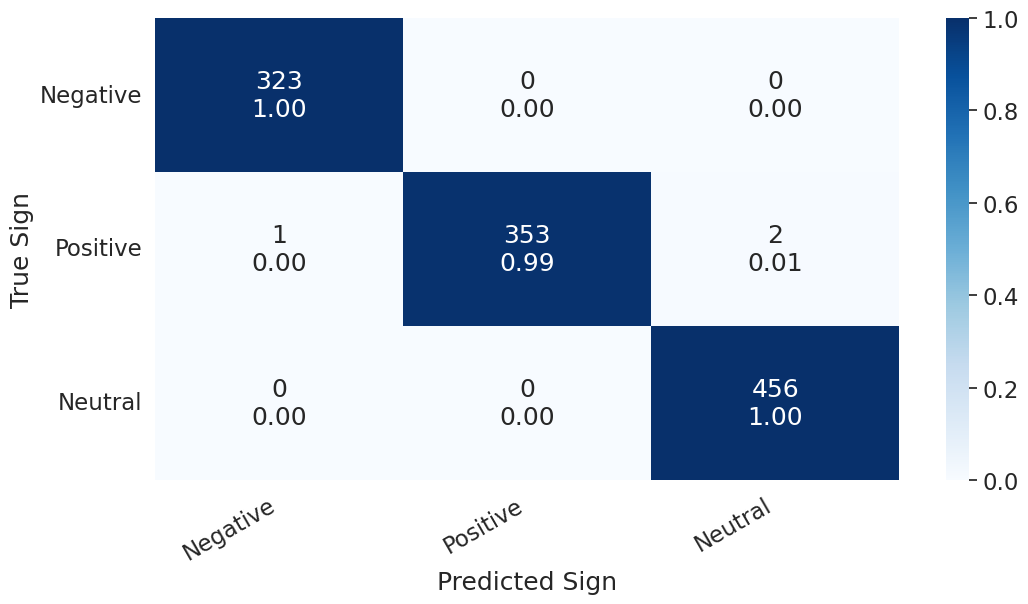

In [ ]:
cm = confusion_matrix(test_labels, final_label)
show_confusion_matrix(cm, class_names)

## Install Shap

In [ ]:
# ==========================================
# 🎨 Beautiful SHAP Visualization (Bangla)
# ==========================================
!pip install shap -q

import shap
import matplotlib.pyplot as plt
from transformers import pipeline
from IPython.display import display, HTML

# -------------------------------
# 1️⃣  Set font for Bangla text
# -------------------------------
!apt-get install fonts-noto-cjk -qq
plt.rcParams['font.family'] = 'Noto Sans Bengali'

# -------------------------------
# 2️⃣  Create pipeline from model
# -------------------------------
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None   # replaces return_all_scores=True
)

# -------------------------------
# 3️⃣  Helper function (Fixed)
# -------------------------------
def shap_explain_bangla(model_pipeline, tokenizer, text_dict, class_names):
    """
    Creates colorful SHAP visualizations for each class (Negative, Positive, Neutral)
    and saves them as interactive HTML.
    """
    masker = shap.maskers.Text(tokenizer, collapse_mask_token=True)
    pmodel = shap.models.TransformersPipeline(model_pipeline, rescale_to_logits=False)
    explainer = shap.Explainer(pmodel, masker)

    # Collect texts
    texts = [text_dict[c] for c in class_names]
    shap_values = explainer(texts)

    for i, label in enumerate(class_names):
        print(f"\n============================")
        print(f"🔹 SHAP Explanation for {label}")
        print("============================\n")
        # Generate text plot
        html = shap.plots.text(shap_values[i, :, i], display=False)
        display(HTML(html)) # Display the HTML directly

        # Save interactive HTML manually
        with open(f"SHAP_{label}.html", "w", encoding="utf-8") as f:
            f.write(html) # Save the HTML string directly
        print(f"💾 Saved colorful interactive plot: SHAP_{label}.html")

# -------------------------------
# 4️⃣  Example usage
# -------------------------------
texts_by_class = {
    'Negative': "তুই মাগিরে মনড়া চায় ১০০ জন মিল্লা চুদি",
    'Positive': "এই সিনেমাটা সত্যিই অসাধারণ! অভিনয় ও সংগীত দুটোই দারুণ।",
    'Neutral' : "সিনেমাটি দুই ঘণ্টা দীর্ঘ এবং বাংলা ভাষায় নির্মিত।"
}

class_names = ['Negative', 'Positive', 'Neutral']

shap_explain_bangla(classifier, tokenizer, texts_by_class, class_names)

Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 126455 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



🔹 SHAP Explanation for Negative



💾 Saved colorful interactive plot: SHAP_Negative.html

🔹 SHAP Explanation for Positive



💾 Saved colorful interactive plot: SHAP_Positive.html

🔹 SHAP Explanation for Neutral



💾 Saved colorful interactive plot: SHAP_Neutral.html


##Waterfall plot

In [ ]:
# ==============================================================
# 🎯 SHAP Waterfall Plots for Bangla Sentiment Classes (3-class)
# ==============================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

# Example Bangla sentences for each class
texts_by_class = {
    'Negative': "তুই মাগিরে মনড়া চায় ১০০ জন মিল্লা চুদি",
    'Positive': "স্রোতে বয়ে গিয়ে অনেক ঠকেছি আমি আগুন",
    'Neutral' : "চুক্তি ভঙ্গের দায়ে এনা প্রোপারটিজকে কি শাস্তি দেয়া হয়েছে?"
}

class_names = ['Negative', 'Positive', 'Neutral']

# Prepare SHAP explainer (using your fine-tuned BERT model)
masker = shap.maskers.Text(tokenizer, collapse_mask_token=True)
pmodel = shap.models.TransformersPipeline(classifier, rescale_to_logits=False)
explainer = shap.Explainer(pmodel, masker)

# Compute SHAP values for the three example sentences
texts = [texts_by_class[c] for c in class_names]
shap_values = explainer(texts)

print("✅ SHAP values computed successfully.")


  0%|          | 0/210 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:13, 13.17s/it]               

✅ SHAP values computed successfully.


/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:230: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:230: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


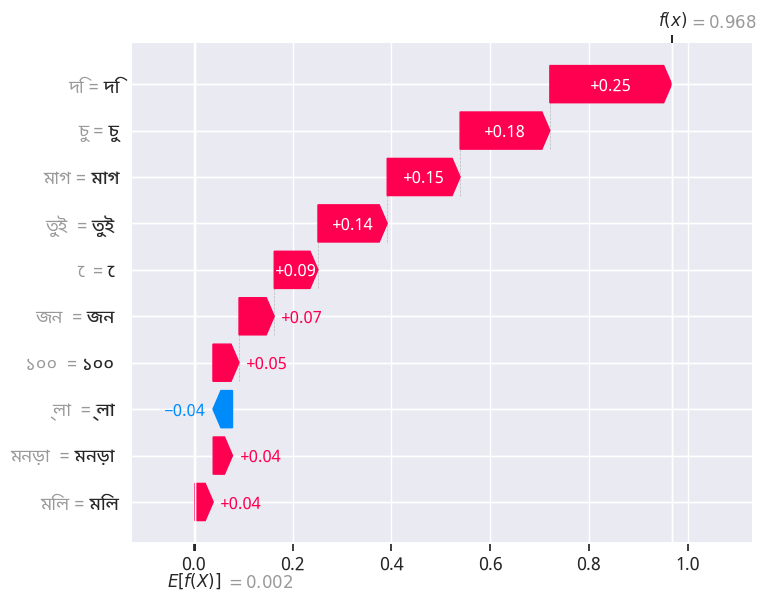

/tmp/ipython-input-1387664481.py:58: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipython-input-1387664481.py:58: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipython-input-1387664481.py:58: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1387664481.py:59: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.savefig(f"SHAP_Waterfall_{class_label}.png", dpi=300, bbox_inches='tight')
/tmp/ipython-input-1387664481.py:59: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.savefig(f"SHAP_Waterfall_{class_label}.png", dpi=300, bbox_inches='tight')
/tmp/ipython-input-1387664481.py:59: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.savefig(f"SHAP_Waterfall_{class_label}.png", dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IP

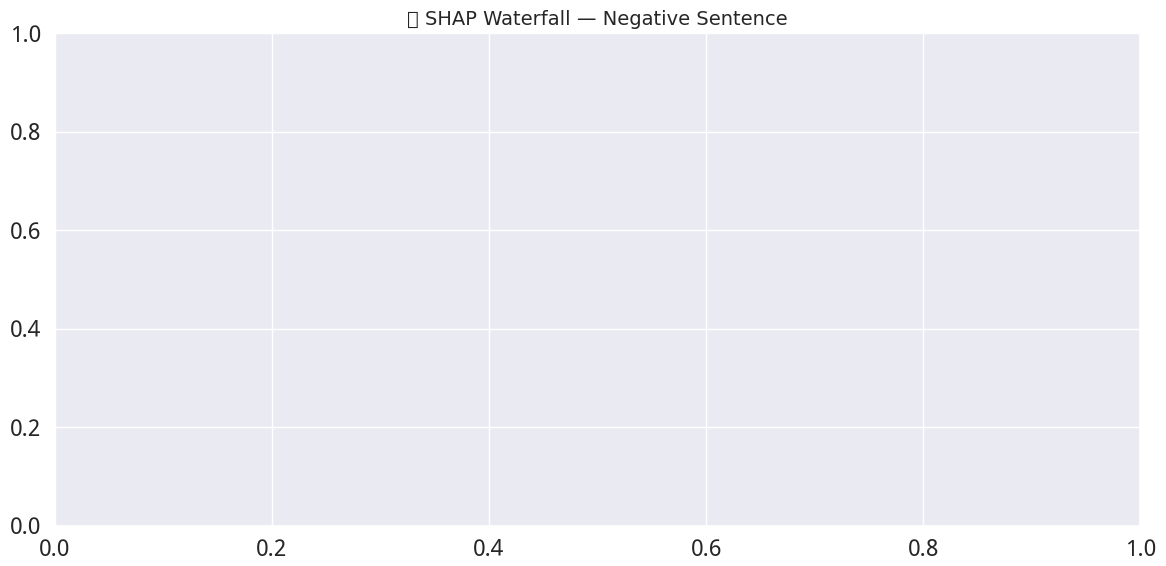

✅ Saved: SHAP_Waterfall_Negative.png


In [ ]:
# ======================================================
# 🧩 Robust SHAP Waterfall for Bangla Sentences (Auto-fix)
# ======================================================

import shap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# ✅ Make sure Bangla font is available
!apt-get install -y fonts-noto-core fonts-noto-extra > /dev/null
bangla_font = "/usr/share/fonts/truetype/noto/NotoSansBengali-Regular.ttf"
font_manager.fontManager.addfont(bangla_font)
rcParams['font.family'] = 'Noto Sans Bengali'


def plot_waterfall_for_class(index, class_label, class_index, shap_values):
    """Plots SHAP waterfall for Bangla text, handling 1D/2D/3D SHAP arrays safely."""

    instance = shap_values[index]
    values = instance.values
    base = instance.base_values
    tokens = np.array(instance.data)

    # 🔍 Detect SHAP shape automatically
    if len(values.shape) == 1:
        # 1D case: one output per token
        token_contribs = values
        base_value = base if np.isscalar(base) else base[0]
    elif len(values.shape) == 2:
        # 2D case: one output vector per token (e.g., [tokens, classes])
        token_contribs = values[:, class_index]
        base_value = base[class_index] if base.ndim > 0 else base
    elif len(values.shape) == 3:
        # 3D case: [samples, tokens, classes]
        token_contribs = values[0, :, class_index]
        base_value = base[0, class_index]
    else:
        raise ValueError(f"❌ Unexpected SHAP value shape: {values.shape}")

    # ✅ Sort top features by absolute SHAP magnitude
    sorted_idx = np.argsort(np.abs(token_contribs))[::-1][:10]
    top_tokens = tokens[sorted_idx]
    top_values = token_contribs[sorted_idx]

    # ✅ Build explanation for waterfall
    exp = shap.Explanation(
        values=top_values,
        base_values=base_value,
        data=top_tokens,
        feature_names=top_tokens
    )

    # ✅ Plot
    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(exp, max_display=10, show=True)
    plt.title(f"💬 SHAP Waterfall — {class_label} Sentence", fontsize=14, fontfamily='DejaVu Sans')
    plt.tight_layout()
    plt.savefig(f"SHAP_Waterfall_{class_label}.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: SHAP_Waterfall_{class_label}.png")


# ======================================================
# 🧠 Example usage
# ======================================================
plot_waterfall_for_class(0, "Negative", 0, shap_values)


/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:230: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:230: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


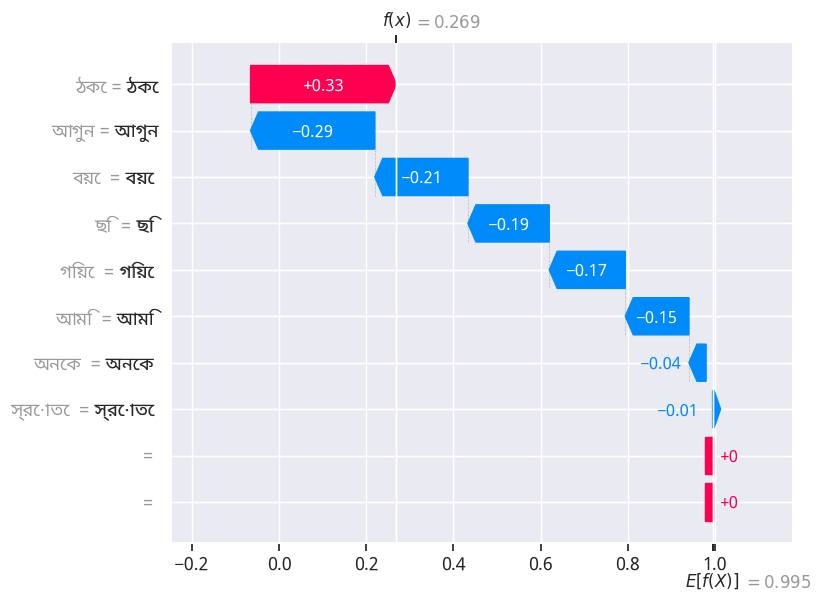

/tmp/ipython-input-1387664481.py:58: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipython-input-1387664481.py:58: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipython-input-1387664481.py:58: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1387664481.py:59: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.savefig(f"SHAP_Waterfall_{class_label}.png", dpi=300, bbox_inches='tight')
/tmp/ipython-input-1387664481.py:59: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.savefig(f"SHAP_Waterfall_{class_label}.png", dpi=300, bbox_inches='tight')
/tmp/ipython-input-1387664481.py:59: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.savefig(f"SHAP_Waterfall_{class_label}.png", dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IP

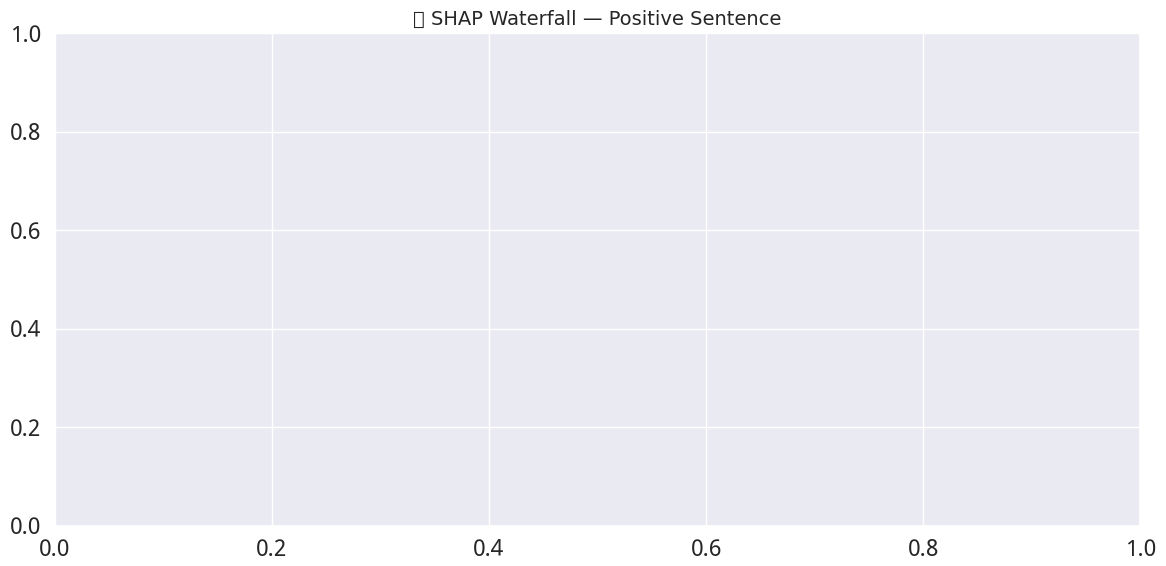

✅ Saved: SHAP_Waterfall_Positive.png


In [ ]:
plot_waterfall_for_class(1, "Positive", 1, shap_values)

/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:230: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/usr/local/lib/python3.12/dist-packages/shap/plots/_waterfall.py:230: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


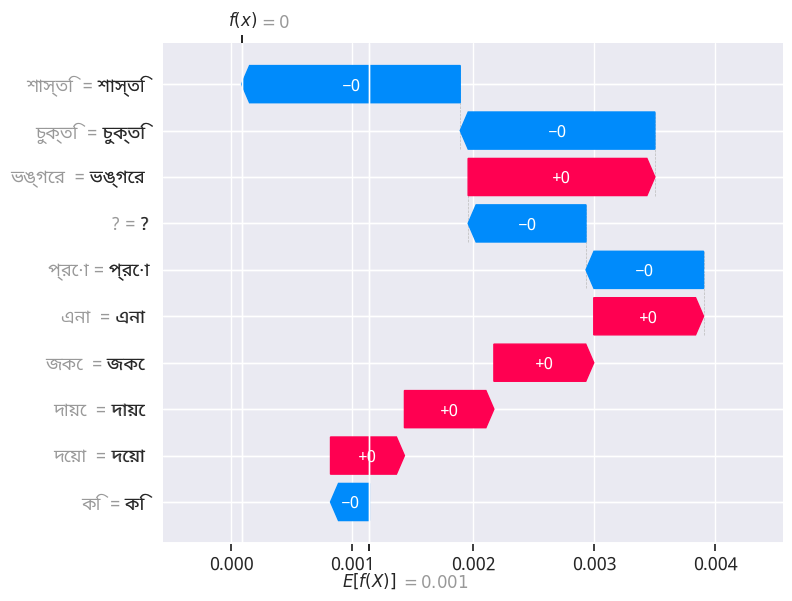

/tmp/ipython-input-1387664481.py:58: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipython-input-1387664481.py:58: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipython-input-1387664481.py:58: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1387664481.py:59: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.savefig(f"SHAP_Waterfall_{class_label}.png", dpi=300, bbox_inches='tight')
/tmp/ipython-input-1387664481.py:59: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.savefig(f"SHAP_Waterfall_{class_label}.png", dpi=300, bbox_inches='tight')
/tmp/ipython-input-1387664481.py:59: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.savefig(f"SHAP_Waterfall_{class_label}.png", dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IP

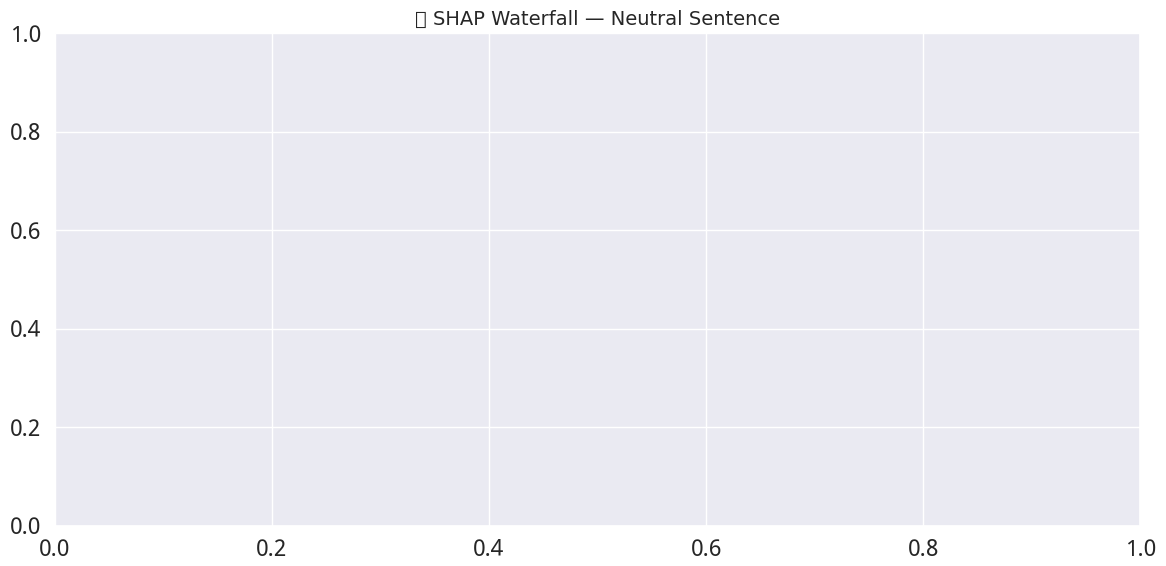

✅ Saved: SHAP_Waterfall_Neutral.png


In [ ]:
plot_waterfall_for_class(2, "Neutral", 2, shap_values)

##Force plot

In [ ]:
import shap

masker = shap.maskers.Text(tokenizer, collapse_mask_token=True)
pmodel = shap.models.TransformersPipeline(classifier, rescale_to_logits=False)
explainer = shap.Explainer(pmodel, masker)


In [ ]:
# ======================================================
# 🎯 SHAP Force Plot for Bangla Sentiment Classification
# ======================================================

import shap

# Example Bangla text (Negative class)
text = "তুই মাগিরে মনড়া চায় ১০০ জন মিল্লা চুদি"

# Compute SHAP values
shap_values = explainer([text])

# Choose which class to visualize
class_index = 0   # 0 = Negative, 1 = Positive, 2 = Neutral

# Extract the SHAP explanation for the first (and only) sample
sample_shap = shap_values[0]

# --- handle different output shapes safely ---
values = sample_shap.values
if values.ndim == 2:
    values = values[:, class_index]

# -----------------------------------------------------
# 🔥 Generate interactive SHAP force plot
# -----------------------------------------------------
shap.initjs()
force_plot = shap.force_plot(
    base_value=sample_shap.base_values[class_index],
    shap_values=values,
    features=sample_shap.data,
    link="logit"
)

# Show in notebook
force_plot


In [ ]:
# Save interactive version for offline viewing
shap.save_html("SHAP_Force_Negative.html", force_plot)
print("✅ Saved: SHAP_Force_Negative.html")


✅ Saved: SHAP_Force_Negative.html


In [ ]:
# ======================================================
# 🎯 SHAP Force Plot for Positive Bangla Sentence
# ======================================================

import shap

# Example Bangla text for Positive sentiment
text = "স্রোতে বয়ে গিয়ে অনেক ঠকেছি আমি আগুন"

# Compute SHAP values
shap_values = explainer([text])

# Choose the class index for Positive sentiment
class_index = 1   # 0 = Negative, 1 = Positive, 2 = Neutral

# Extract SHAP explanation for this sample
sample_shap = shap_values[0]

# Handle different output shapes (1D or 2D)
values = sample_shap.values
if values.ndim == 2:
    values = values[:, class_index]

# -----------------------------------------------------
# 🔥 Generate interactive SHAP force plot
# -----------------------------------------------------
shap.initjs()
force_plot = shap.force_plot(
    base_value=sample_shap.base_values[class_index],
    shap_values=values,
    features=sample_shap.data,
    link="logit"
)

# Display in notebook
force_plot


In [ ]:
# Save interactive HTML version
shap.save_html("SHAP_Force_Positive.html", force_plot)
print("✅ Saved interactive force plot: SHAP_Force_Positive.html")


✅ Saved interactive force plot: SHAP_Force_Positive.html


In [ ]:
# ======================================================
# 🎯 SHAP Force Plot for Neutral Bangla Sentence
# ======================================================

import shap

# Example Bangla text for Neutral sentiment
text = "চুক্তি ভঙ্গের দায়ে এনা প্রোপারটিজকে কি শাস্তি দেয়া হয়েছে?"

# Compute SHAP values
shap_values = explainer([text])

# Choose the class index for Neutral
class_index = 2   # 0 = Negative, 1 = Positive, 2 = Neutral

# Extract the SHAP explanation for this sample
sample_shap = shap_values[0]

# Handle both 1D and 2D SHAP output shapes
values = sample_shap.values
if values.ndim == 2:
    values = values[:, class_index]

# -----------------------------------------------------
# 🔥 Generate interactive SHAP force plot
# -----------------------------------------------------
shap.initjs()
force_plot = shap.force_plot(
    base_value=sample_shap.base_values[class_index],
    shap_values=values,
    features=sample_shap.data,
    link="logit"
)

# Display interactive force plot in notebook
force_plot


  0%|          | 0/210 [00:00<?, ?it/s]

In [ ]:
# Save the interactive force plot to HTML
shap.save_html("SHAP_Force_Neutral.html", force_plot)
print("✅ Saved interactive force plot: SHAP_Force_Neutral.html")


✅ Saved interactive force plot: SHAP_Force_Neutral.html


##Install Lime

In [ ]:
# ======================================================
# 🎯 LIME Explainability for Bangla Sentiment Model
# ======================================================

!pip install lime -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline
from transformers import pipeline


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
lime_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True
)

Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [ ]:
# ======================================================
# ✅ FIXED predict_proba to correct class mapping
# ======================================================
def predict_proba(texts):
    results = lime_pipeline(texts)
    probs = []
    for item in results:
        # Manually map LABEL_0→Negative, LABEL_2→Neutral, LABEL_1→Positive
        ordered_scores = [0.0, 0.0, 0.0]
        for entry in item:
            if entry["label"] in ["LABEL_0", "negative"]:
                ordered_scores[0] = entry["score"]
            elif entry["label"] in ["LABEL_1", "positive"]:
                ordered_scores[1] = entry["score"]  # note the swap
            elif entry["label"] in ["LABEL_2", "neutral"]:
                ordered_scores[2] = entry["score"]  # note the swap
        probs.append(ordered_scores)
    return np.array(probs)


In [ ]:
model.eval()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(102025, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [ ]:
examples = {
    "Negative": "খানকি তুই পরকাল বিশ্বাস করিস না .শালি তোর গায়ে ঠাডা পড়বে .",
    "Positive": "কোটা বাতিলের সিদ্ধান্তে অটল থাকতে হবে।",
    "Neutral": "আমাদের জন্য সবচেয়ে বড় চ্যালেঞ্জ হচ্ছে আজ ।"
}

# Quick sanity-check
print("\n🔍 Probability Check:")
for lbl, txt in examples.items():
    print(f"{lbl} →", dict(zip(class_names, np.round(predict_proba([txt])[0], 4))))


🔍 Probability Check:
Negative → {'Negative': np.float64(0.9966), 'Positive': np.float64(0.0003), 'Neutral': np.float64(0.0004)}
Positive → {'Negative': np.float64(0.0003), 'Positive': np.float64(0.9957), 'Neutral': np.float64(0.0013)}
Neutral → {'Negative': np.float64(0.0003), 'Positive': np.float64(0.005), 'Neutral': np.float64(0.9927)}


In [ ]:
# ======================================================
# ✅ Create LIME Text Explainer (Fix)
# ======================================================

from lime.lime_text import LimeTextExplainer

# Define your Bangla sentiment class names (if not done yet)
class_names = ['Negative', 'Positive', 'Neutral']

# Initialize the LIME explainer (for Bangla text)
explainer = LimeTextExplainer(class_names=class_names)

print("✅ LIME Text Explainer created successfully!")

✅ LIME Text Explainer created successfully!


In [ ]:
from IPython.display import display, HTML

for label, text in examples.items():
    print(f"\n============================")
    print(f"🔹 LIME Explanation for {label}")
    print("============================")

    # Generate explanation
    exp = explainer.explain_instance(
        text_instance=text,
        classifier_fn=predict_proba,
        num_features=10,
        labels=list(range(len(class_names)))
    )

    # Save HTML file
    html_path = f"LIME_{label}.html"
    exp.save_to_file(html_path)
    print(f"✅ Saved: {html_path}")

    # ✅ Correct inline display
    display(HTML(exp.as_html()))



🔹 LIME Explanation for Negative
✅ Saved: LIME_Negative.html



🔹 LIME Explanation for Positive
✅ Saved: LIME_Positive.html



🔹 LIME Explanation for Neutral
✅ Saved: LIME_Neutral.html
